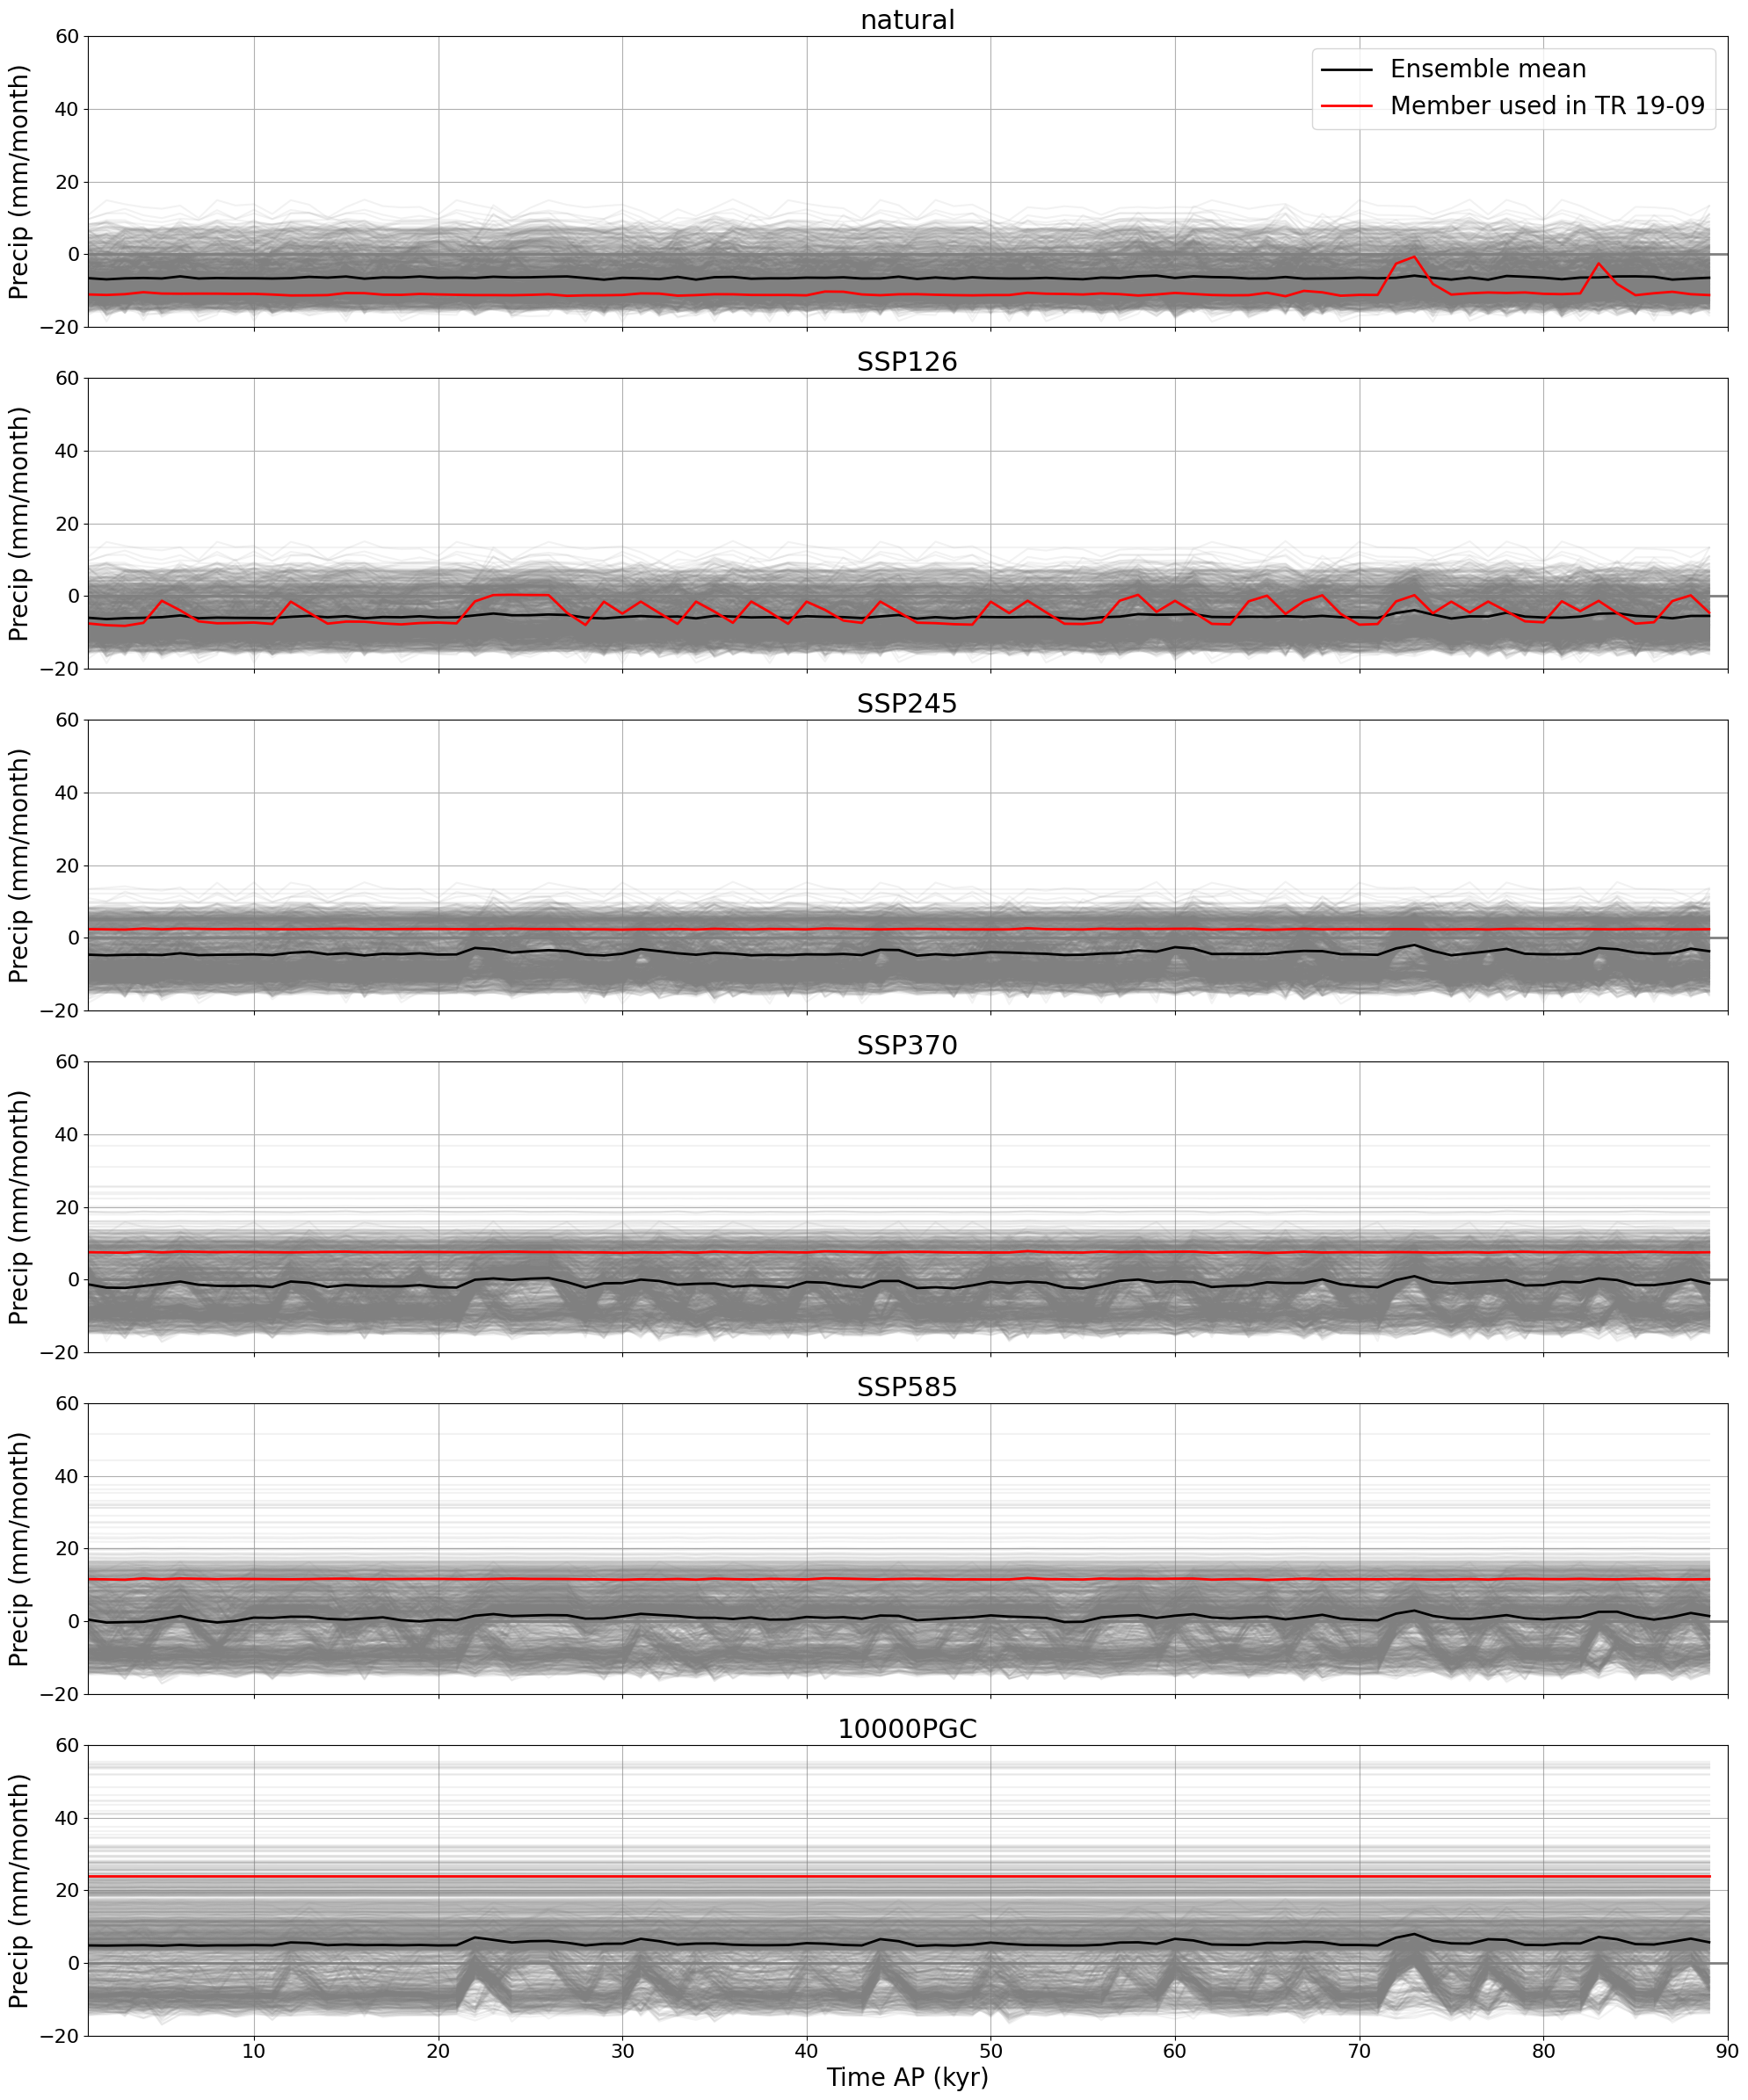

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 配置参数
var = 'pr'
site_num = 34
scenarios = ["natural", "SSP126", "SSP245", "SSP370", "SSP585", "10000PGC"]
var_names = {'tas': 'Temp', 'pr': 'Precip'}
units = {'tas': '°C', 'pr': 'mm/month'}
path = "/Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/TONIC-Oligocene/NWS_emulation/prediction/results_on_sites/high_reso_sites/"

# 当前高分辨率站点 txt 的格式是：每一行一个 ensemble member，每一列一个时间步
data_by_scen = []
global_min = np.inf
global_max = -np.inf

for scenario in scenarios:
    txt_path = f'{path}site_{site_num}/{var}_{scenario}_UK_site{site_num}.txt'
    if not os.path.exists(txt_path):
        print(f'{txt_path} not found, skip.')
        data_by_scen.append(None)
        continue

    data = np.loadtxt(txt_path, comments='#')
    data = np.atleast_2d(data)

    data_by_scen.append(data)
    global_min = min(global_min, data.min())
    global_max = max(global_max, data.max())

n_scen = len(scenarios)
fig, axes = plt.subplots(n_scen, 1, figsize=(20, 4 * n_scen), sharex=True)
if n_scen == 1:
    axes = [axes]

for i_scen, scenario in enumerate(scenarios):
    data = data_by_scen[i_scen]
    ax = axes[i_scen]
    ax.axhline(0, color='grey', linewidth=2)

    if data is not None:
        n_members, n_timesteps = data.shape
        x = np.arange(1, n_timesteps + 1)

        for i_member in range(n_members):
            ax.plot(x, data[i_member, :], color='grey', alpha=0.1)

        ax.plot(x, data.mean(axis=0), color='black', label='Ensemble mean', linewidth=2)

        if n_members > 66:
            ax.plot(x, data[66, :], color='red', label='Member used in TR 19-09', linewidth=2)

        if var == 'tas':
            ax.set_ylim(-17.5, 12.5)
        if var == 'pr':
            ax.set_ylim(-20, 60)

        ax.grid()
        ax.set_xlim(1, n_timesteps)
        ax.tick_params(axis='both', labelsize=16)

        if scenario == 'natural':
            ax.legend(fontsize=20, loc='upper right')

        ax.set_ylabel(f'{var_names[var]} ({units[var]})', fontsize=20)
        ax.set_title(f'{scenario}', fontsize=22)
    else:
        ax.set_title(f'{scenario} data not found', fontsize=22)

axes[-1].set_xlabel('Time AP (kyr)', fontsize=20)
plt.tight_layout()
plt.savefig(f"{var}_site{site_num}_downscaled")
plt.show()